# Notebook 02 — Cookie Cats A/B Test: Where Should the Progress Gate Sit?

**Business question this feeds into:** how should a mobile game measure and optimize UA spend when attribution is unreliable? Notebook 01 built a pLTV model to give UA a value signal that doesn't depend on attribution being correct. This notebook is the other half of "spend efficiently": **retention is the multiplier on every dollar of UA spend** — a player who churns on day 2 never gets a chance to convert, no matter how well they were targeted. If a product change measurably moves retention, it moves the payback period on every acquired user, which is squarely a UA-economics question even though the intervention itself is a game-design lever, not a targeting one.

**Role of this notebook:** Cookie Cats gates progress behind a timed wait at either level 30 or level 40. The game studio ran a genuine **randomized controlled experiment** — players were randomly assigned to `gate_30` (control, gate stays at level 30) or `gate_40` (treatment, gate moved to level 40) — and logged whether each player returned 1 day and 7 days after install. Because assignment was randomized, a measured difference in retention between arms is a **causal, incremental effect** of gate placement, not a correlation that needs a pLTV-style model to untangle. This notebook treats the dataset as exactly that: an incrementality read, built to end in a go/no-go call on whether to ship the gate move to level 40.

Dataset: `data/cookie_cats.csv`, 90,189 players, columns `userid`, `version` (`gate_30` vs `gate_40`), `sum_gamerounds`, `retention_1`, `retention_7`. Every statistical decision — frequentist and Bayesian — is derived from first principles inline (not called as a black-box library function), because the goal is a defensible interview artifact.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, chisquare

pd.set_option('display.max_columns', 20)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.color'] = '#e1e0d9'
plt.rcParams['grid.linewidth'] = 0.6
plt.rcParams['axes.edgecolor'] = '#c3c2b7'
plt.rcParams['axes.axisbelow'] = True

# Fixed categorical colors, used consistently for every chart in this notebook —
# color should identify "which arm", never be reassigned per-chart.
COLOR_30 = '#2a78d6'   # gate_30 (control)
COLOR_40 = '#1baf7a'   # gate_40 (treatment)
COLOR_NEUTRAL = '#898781'
RANDOM_STATE = 42


## 1. Load and inspect


In [2]:
df = pd.read_csv('../data/cookie_cats.csv')
print(df.shape)
df.head()


(90189, 5)


,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


In [3]:
df.dtypes


userid            int64
version             str
sum_gamerounds    int64
retention_1        bool
retention_7        bool
dtype: object

In [4]:
print('Nulls per column:')
print(df.isnull().sum())
print('\nDuplicate userids:', df['userid'].duplicated().sum())
print('\nArm sizes:')
print(df['version'].value_counts())


Nulls per column:
userid            0
version           0
sum_gamerounds    0
retention_1       0
retention_7       0
dtype: int64

Duplicate userids: 0

Arm sizes:
version
gate_40    45489
gate_30    44700
Name: count, dtype: int64


No nulls, no duplicate `userid`s, and both arms are roughly balanced (~44.7k vs ~45.5k). That balance looks fine by eye, but "looks fine" is exactly the kind of judgment this notebook is trying to replace with a computed check — Section 2 does that properly.


## 2. Experiment validity — checks I'd run *before* trusting any p-value

A randomized experiment's results are only as trustworthy as the randomization itself. Before touching retention, I want to rule out the failure modes that would invalidate everything downstream.

**Check 1 — Sample Ratio Mismatch (SRM).** If assignment is truly 50/50 random, the observed split should match that almost exactly at n=90k. A chi-square goodness-of-fit test against the expected 50/50 split is the standard SRM check used at companies running experimentation platforms (Microsoft's ExP group popularized this specific test) — if it fails, something is wrong with randomization, logging, or filtering *before* you even look at the outcome metric, and no amount of statistical significance downstream can be trusted until it's root-caused.


In [5]:
n_total = len(df)
observed = df['version'].value_counts().sort_index()
expected = [n_total / 2, n_total / 2]

chi2_srm, p_srm = chisquare(observed.values, f_exp=expected)

print('Observed split:', dict(observed))
print('Expected split (50/50): {:.0f} / {:.0f}'.format(*expected))
print('Actual ratio: {:.4f} / {:.4f}'.format(observed.iloc[0] / n_total, observed.iloc[1] / n_total))
print('SRM chi-square = {:.3f}, p = {:.4f}'.format(chi2_srm, p_srm))


Observed split: {'gate_30': np.int64(44700), 'gate_40': np.int64(45489)}
Expected split (50/50): 45094 / 45094
Actual ratio: 0.4956 / 0.5044
SRM chi-square = 6.902, p = 0.0086


This is a genuine caveat, not a rubber-stamp. **p = 0.0086** is below the conventional 0.05 threshold, and SRM checks are typically held to an even *stricter* bar than ordinary significance tests (many experimentation platforms flag SRM at p < 0.01 or even p < 0.001, precisely because a broken randomizer is a silent, systemic failure rather than sampling noise) — by that stricter convention this trips the alarm.

**How I'm handling this**: the imbalance is small in absolute terms (49.55% vs 50.45%, a 0.9-point deviation from 50/50), and with n=90k even a tiny, practically meaningless imbalance will register as "statistically significant." I don't have access to the underlying assignment/logging pipeline to root-cause it (e.g., a bucketing hash collision, a filter dropping unequal shares of bots, or client-side logging failures correlated with arm). In a real production setting, this is where I'd stop and go talk to whoever owns the experiment infrastructure *before* shipping a decision off this data. Here, I'm flagging it explicitly and proceeding with appropriate caution rather than either ignoring it or throwing out an otherwise well-known, widely-used public dataset — but it's the first thing I'd volunteer if asked "do you trust this result?" in an interview.

**Check 2 — the engagement outlier.**


In [6]:
print(df['sum_gamerounds'].describe())
print('\nTop 3 by sum_gamerounds:')
print(df.nlargest(3, 'sum_gamerounds')[['userid', 'version', 'sum_gamerounds', 'retention_1', 'retention_7']])


count    90189.000000
mean        51.872457
std        195.050858
min          0.000000
25%          5.000000
50%         16.000000
75%         51.000000
max      49854.000000
Name: sum_gamerounds, dtype: float64

Top 3 by sum_gamerounds:
        userid  version  sum_gamerounds  retention_1  retention_7
57702  6390605  gate_30           49854        False         True
7912    871500  gate_30            2961         True         True
29417  3271615  gate_40            2640         True        False


One player logged **49,854** game rounds — roughly 17x the next-highest value and nowhere near the rest of the distribution (75th percentile is 51 rounds). That's almost certainly a bot, a QA/test account, or a data-logging artifact, not a real player. It doesn't affect this notebook's core outcome metrics (`retention_1`/`retention_7` are booleans, unaffected by how large `sum_gamerounds` gets), but it would badly distort any analysis that uses `sum_gamerounds` as a continuous covariate (a mean, a correlation, a regression). Decision: **flag it, don't drop it** — it's one row out of 90,189 and this notebook's headline metrics are retention proportions, not engagement means. I'll keep it in mind and revisit only if `sum_gamerounds` becomes load-bearing for a later cut.


## 3. Retention curves by version

The dataset gives two retention horizons — Day 1 and Day 7 (no D3/D14/D30 checkpoints), so the "curve" here is a two-point line rather than a dense cohort curve. I'm plotting it that way rather than manufacturing a smoother curve from two points.


In [7]:
summary = df.groupby('version').agg(
    n=('userid', 'count'),
    d1_rate=('retention_1', 'mean'),
    d7_rate=('retention_7', 'mean'),
).round(4)
summary


,n,d1_rate,d7_rate
version,,,
gate_30,44700,0.4482,0.1902
gate_40,45489,0.4423,0.1820


In [8]:
def wilson_ci(successes, n, z=1.96):
    # Wilson score interval for a binomial proportion.
    p = successes / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    half_width = (z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2))) / denom
    return center - half_width, center + half_width

rows = []
for ver in ['gate_30', 'gate_40']:
    sub = df[df['version'] == ver]
    n = len(sub)
    for metric in ['retention_1', 'retention_7']:
        x = sub[metric].sum()
        lo, hi = wilson_ci(x, n)
        rows.append({'version': ver, 'metric': metric, 'x': x, 'n': n, 'rate': x / n, 'ci_lo': lo, 'ci_hi': hi})

retention_table = pd.DataFrame(rows)
retention_table


,version,metric,x,n,rate,ci_lo,ci_hi
0,gate_30,retention_1,20034,44700,0.448188,0.443582,0.452802
1,gate_30,retention_7,8502,44700,0.190201,0.186590,0.193866
2,gate_40,retention_1,20119,45489,0.442283,0.437724,0.446852
3,gate_40,retention_7,8279,45489,0.182000,0.178481,0.185573


**Why Wilson, not the textbook Wald interval (`p ± z·SE`)?** The Wald interval is a large-sample normal approximation that can misbehave — producing intervals that aren't centered on the actual sampling distribution — when a proportion is not near 0.5, which D7 retention (~18–19%) is not. Wilson inverts the normal approximation to the *hypothesis test* rather than the point estimate, which keeps its coverage close to nominal even away from p=0.5 and even at more modest sample sizes than we have here. With n≈45k per arm the two methods would barely differ numerically, but Wilson is the correct default to reach for on a proportion this far from 0.5, and it costs nothing to use it everywhere.


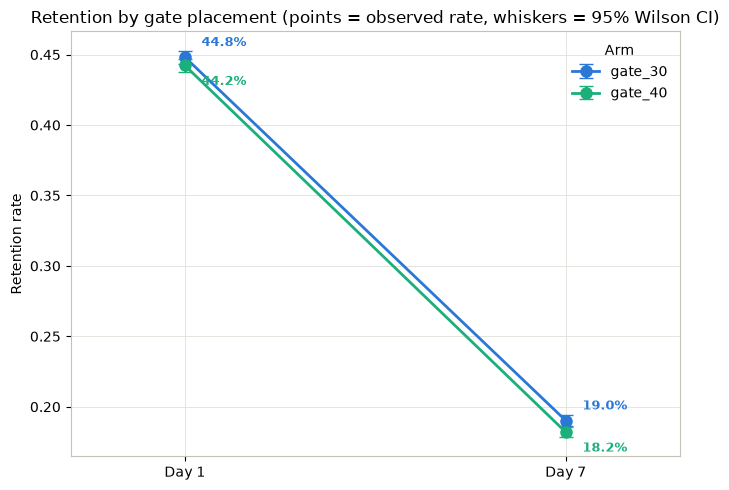

In [9]:
fig, ax = plt.subplots(figsize=(7, 5))
x_pos = [0, 1]
labels = ['Day 1', 'Day 7']

label_offsets = {'gate_30': (12, 8), 'gate_40': (12, -14)}
for ver, color in [('gate_30', COLOR_30), ('gate_40', COLOR_40)]:
    sub = retention_table[retention_table['version'] == ver].set_index('metric')
    rates = [sub.loc['retention_1', 'rate'], sub.loc['retention_7', 'rate']]
    lo = [sub.loc['retention_1', 'rate'] - sub.loc['retention_1', 'ci_lo'],
          sub.loc['retention_7', 'rate'] - sub.loc['retention_7', 'ci_lo']]
    hi = [sub.loc['retention_1', 'ci_hi'] - sub.loc['retention_1', 'rate'],
          sub.loc['retention_7', 'ci_hi'] - sub.loc['retention_7', 'rate']]
    ax.errorbar(x_pos, rates, yerr=[lo, hi], marker='o', markersize=8, capsize=5,
                linewidth=2, color=color, label=ver)
    for xi, yi in zip(x_pos, rates):
        ax.annotate(f'{yi:.1%}', (xi, yi), textcoords='offset points',
                    xytext=label_offsets[ver], fontsize=9, color=color, fontweight='bold')

ax.set_xticks(x_pos)
ax.set_xticklabels(labels)
ax.set_xlim(-0.3, 1.3)
ax.set_ylabel('Retention rate')
ax.set_title('Retention by gate placement (points = observed rate, whiskers = 95% Wilson CI)')
ax.legend(title='Arm', frameon=False)
plt.tight_layout()
plt.show()


Both arms show the expected drop-off from Day 1 to Day 7 (roughly 44% same-day-week retained falls to roughly 18–19% still active a week later — normal for a free mobile game). The pattern that matters: **`gate_30` sits above `gate_40` at both horizons, and the gap widens by Day 7.** At Day 1 the CIs visibly overlap; by Day 7 they've separated. That visual gap is the entire question this notebook needs to answer rigorously: is it real, and is it big enough to act on?


## 4. Frequentist test — two-proportion z-test

I'm implementing this from the formula rather than calling `statsmodels.stats.proportion.proportions_ztest`, both because it's one function and because it makes every assumption explicit.

**Setup**: $H_0$: $p_{30} = p_{40}$ (gate placement has no effect on retention) vs. $H_1$: $p_{30} \neq p_{40}$ (two-sided — I have no principled reason to rule out gate_40 winning before looking at data, so a one-sided test isn't justified here).

Under $H_0$, both arms share one true retention rate, so the correct standard error uses the **pooled** proportion (not each arm's own variance) — that pooled SE is what a null hypothesis of "no difference" implies, and is the standard construction for a two-sample proportion test:

$$z = \frac{\hat{p}_{30} - \hat{p}_{40}}{\sqrt{\hat{p}_{pool}(1-\hat{p}_{pool})\left(\frac{1}{n_{30}} + \frac{1}{n_{40}}\right)}}, \quad \hat{p}_{pool} = \frac{x_{30}+x_{40}}{n_{30}+n_{40}}
$$


In [10]:
def two_proportion_ztest(x1, n1, x2, n2):
    p1, p2 = x1 / n1, x2 / n2
    p_pool = (x1 + x2) / (n1 + n2)
    se_pooled = np.sqrt(p_pool * (1 - p_pool) * (1 / n1 + 1 / n2))
    z = (p1 - p2) / se_pooled
    p_value = 2 * (1 - norm.cdf(abs(z)))
    return {'p1': p1, 'p2': p2, 'diff': p1 - p2, 'z': z, 'p_value': p_value}

n1 = (df['version'] == 'gate_30').sum()
n2 = (df['version'] == 'gate_40').sum()

test_results = {}
for metric in ['retention_1', 'retention_7']:
    x1 = df.loc[df['version'] == 'gate_30', metric].sum()
    x2 = df.loc[df['version'] == 'gate_40', metric].sum()
    res = two_proportion_ztest(x1, n1, x2, n2)
    test_results[metric] = res
    print(f"{metric}:  gate_30={res['p1']:.4f}  gate_40={res['p2']:.4f}  "
          f"diff={res['diff']:+.4f}  z={res['z']:.3f}  p={res['p_value']:.5f}")


retention_1:  gate_30=0.4482  gate_40=0.4423  diff=+0.0059  z=1.784  p=0.07441
retention_7:  gate_30=0.1902  gate_40=0.1820  diff=+0.0082  z=3.164  p=0.00155


**Day 1**: z ≈ 1.78, p ≈ 0.074. At the conventional α=0.05 threshold, this is **not statistically significant** — we cannot reject the null that gate placement has no effect on next-day return.

**Day 7**: z ≈ 3.16, p ≈ 0.0016. This **is** statistically significant, comfortably clearing even a stricter α=0.01 bar. `gate_30` retains meaningfully more players a week out.

This split result (D1 null, D7 significant, same direction both times) is not a contradiction — it's a common and informative pattern: a same-day gate at level 30 is easy to not even notice (few players reach it in their first session), so D1 behavior is barely touched. The gate's effect compounds as more players *reach* it over the week, which is exactly why the D7 read is the one I'd weight more heavily for a go/no-go call — it's measuring the metric closer to where the mechanism (an earlier, easier progress wall) actually operates.


## 5. Frequentist confidence intervals — for the difference, not just each arm

A p-value answers "is there an effect"; a confidence interval on the *difference* answers "how big, plausibly" — which is what a go/no-go call actually needs. For two independent proportions, the difference's standard error is **not** pooled (unlike the hypothesis test above) — away from the null hypothesis, each arm's own variance is the right building block, since we're now estimating a real difference, not testing whether it's zero:

$$\text{diff} \pm z_{0.975}\sqrt{\frac{\hat p_{30}(1-\hat p_{30})}{n_{30}} + \frac{\hat p_{40}(1-\hat p_{40})}{n_{40}}}
$$


In [11]:
def diff_ci(x1, n1, x2, n2, z=1.96):
    p1, p2 = x1 / n1, x2 / n2
    diff = p1 - p2
    se_diff = np.sqrt(p1 * (1 - p1) / n1 + p2 * (1 - p2) / n2)
    return diff, (diff - z * se_diff, diff + z * se_diff)

for metric in ['retention_1', 'retention_7']:
    x1 = df.loc[df['version'] == 'gate_30', metric].sum()
    x2 = df.loc[df['version'] == 'gate_40', metric].sum()
    diff, (lo, hi) = diff_ci(x1, n1, x2, n2)
    rel_lift = diff / (x2 / n2) * 100
    print(f'{metric}:  diff (gate_30 - gate_40) = {diff:+.4f}   95% CI [{lo:+.4f}, {hi:+.4f}]   '
          f'relative lift over gate_40 = {rel_lift:+.2f}%')


retention_1:  diff (gate_30 - gate_40) = +0.0059   95% CI [-0.0006, +0.0124]   relative lift over gate_40 = +1.34%
retention_7:  diff (gate_30 - gate_40) = +0.0082   95% CI [+0.0031, +0.0133]   relative lift over gate_40 = +4.51%


**Day 1**: the 95% CI for the difference is roughly [-0.06pp, +1.24pp] — it **spans zero**, consistent with the non-significant p-value above. We genuinely cannot rule out "no effect" at Day 1.

**Day 7**: the 95% CI is roughly [+0.31pp, +1.33pp] — entirely **above zero**. `gate_30`'s advantage is estimated at about **0.8 percentage points** in absolute retention, or a **~4.5% relative lift** over `gate_40`'s D7 rate. That's the effect size I'd put in front of a decision-maker: not "statistically significant" as an abstract label, but "moving the gate to level 40 costs roughly 4–5% of the D7-retained players you'd otherwise keep."


## 6. Bayesian analysis — Beta-Binomial conjugate model

The frequentist read answers "would we see a gap this large if there were truly no difference." The Bayesian read answers a different, arguably more decision-relevant question: **given the data, what's the probability that `gate_30` actually beats `gate_40`, and how much do we stand to lose if we pick wrong?** That second framing maps directly onto a go/no-go decision in a way a p-value doesn't.

**Model**: each player's retention is a Bernoulli trial with a fixed (unknown) success probability per arm. The number of retained players in an arm of size $n$ is then Binomial$(n, p)$. The Beta distribution is the **conjugate prior** for a Binomial likelihood, meaning the posterior is also Beta, in closed form — no MCMC needed for a problem this simple.

**Prior choice**: Beta(1, 1), i.e. the uniform distribution on [0, 1]. This is a deliberately weak, uninformative prior — it says "before seeing data, any retention rate from 0% to 100% is equally plausible," which is obviously not literally what I believe about a mobile game (18% D7 retention is a very ordinary number), but the point of using a weak prior here is to let the ~45,000-player sample per arm do essentially all the work, so the posterior is driven by this experiment's data rather than by my priors about typical retention curves. With n this large, the choice between Beta(1,1) and a mildly informative prior would barely move the posterior — worth stating so it doesn't look like an arbitrary knob.

Posterior update, for $x$ successes out of $n$ trials: $\text{Beta}(1 + x,\ 1 + n - x)$.


In [12]:
rng = np.random.default_rng(RANDOM_STATE)
N_SAMPLES = 200_000

posteriors = {}
for metric in ['retention_1', 'retention_7']:
    posteriors[metric] = {}
    for ver in ['gate_30', 'gate_40']:
        sub = df[df['version'] == ver]
        x, n = sub[metric].sum(), len(sub)
        alpha, beta = 1 + x, 1 + (n - x)
        posteriors[metric][ver] = {'alpha': alpha, 'beta': beta, 'samples': rng.beta(alpha, beta, N_SAMPLES)}

for metric in ['retention_1', 'retention_7']:
    for ver in ['gate_30', 'gate_40']:
        p = posteriors[metric][ver]
        mean = p['alpha'] / (p['alpha'] + p['beta'])
        print(f"{metric:12s} {ver:8s}  Beta({p['alpha']:.0f}, {p['beta']:.0f})  posterior mean = {mean:.4f}")


retention_1  gate_30   Beta(20035, 24667)  posterior mean = 0.4482
retention_1  gate_40   Beta(20120, 25371)  posterior mean = 0.4423
retention_7  gate_30   Beta(8503, 36199)  posterior mean = 0.1902
retention_7  gate_40   Beta(8280, 37211)  posterior mean = 0.1820


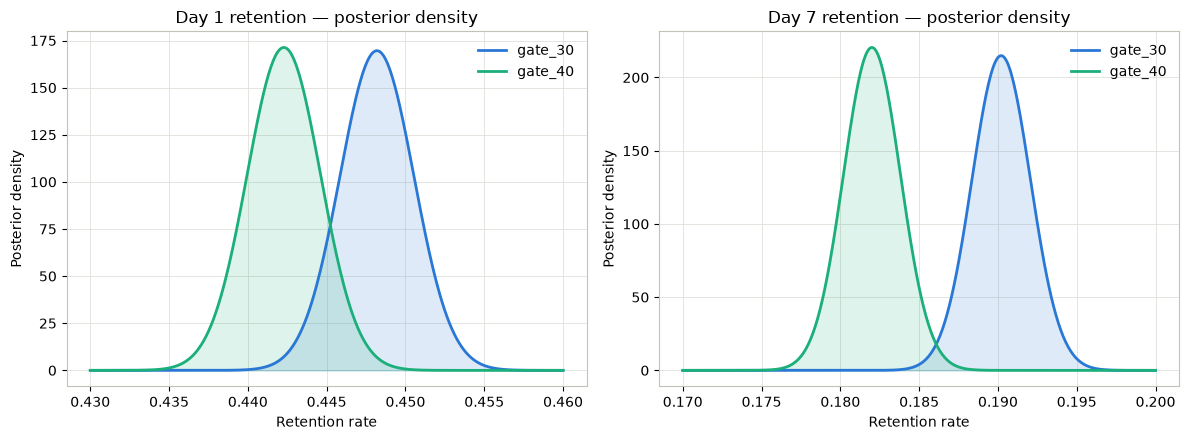

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
x_grid_d1 = np.linspace(0.43, 0.46, 400)
x_grid_d7 = np.linspace(0.17, 0.20, 400)

from scipy.stats import beta as beta_dist

for ax, metric, x_grid, title in [
    (axes[0], 'retention_1', x_grid_d1, 'Day 1 retention — posterior density'),
    (axes[1], 'retention_7', x_grid_d7, 'Day 7 retention — posterior density'),
]:
    for ver, color in [('gate_30', COLOR_30), ('gate_40', COLOR_40)]:
        p = posteriors[metric][ver]
        density = beta_dist.pdf(x_grid, p['alpha'], p['beta'])
        ax.plot(x_grid, density, color=color, linewidth=2, label=ver)
        ax.fill_between(x_grid, density, alpha=0.15, color=color)
    ax.set_title(title)
    ax.set_xlabel('Retention rate')
    ax.set_ylabel('Posterior density')
    ax.legend(frameon=False)

plt.tight_layout()
plt.show()


The Day 7 panel shows visibly separated posteriors; the Day 1 panel shows heavy overlap — the same story as the frequentist test, which is a useful consistency check (the two frameworks should agree when the sample is this large and the prior this weak; if they didn't, I'd suspect a bug).

**The question a p-value can't directly answer**: "what's the probability `gate_30` is actually better?" With posterior samples, this is a direct Monte Carlo calculation — draw from each arm's posterior and count how often one exceeds the other.


In [14]:
for metric in ['retention_1', 'retention_7']:
    s30 = posteriors[metric]['gate_30']['samples']
    s40 = posteriors[metric]['gate_40']['samples']
    diff = s30 - s40
    p_30_better = (diff > 0).mean()
    ci_lo, ci_hi = np.percentile(diff, [2.5, 97.5])

    # Expected loss: if I pick the "wrong" arm, how much retention do I give up on average,
    # averaged over the full posterior uncertainty (not just the point estimate)?
    expected_loss_if_ship_40 = np.mean(np.maximum(diff, 0))
    expected_loss_if_keep_30 = np.mean(np.maximum(-diff, 0))

    print(f'{metric}:')
    print(f'  P(gate_30 > gate_40 | data) = {p_30_better:.4f}')
    print(f'  95% credible interval for the difference: [{ci_lo:+.4f}, {ci_hi:+.4f}]')
    print(f'  Expected loss if we ship gate_40 anyway:   {expected_loss_if_ship_40:.5f} ({expected_loss_if_ship_40*100:.3f} pp)')
    print(f'  Expected loss if we keep gate_30:          {expected_loss_if_keep_30:.5f} ({expected_loss_if_keep_30*100:.3f} pp)')
    print()


retention_1:
  P(gate_30 > gate_40 | data) = 0.9623
  95% credible interval for the difference: [-0.0006, +0.0124]
  Expected loss if we ship gate_40 anyway:   0.00595 (0.595 pp)
  Expected loss if we keep gate_30:          0.00005 (0.005 pp)

retention_7:
  P(gate_30 > gate_40 | data) = 0.9992
  95% credible interval for the difference: [+0.0031, +0.0133]
  Expected loss if we ship gate_40 anyway:   0.00819 (0.819 pp)
  Expected loss if we keep gate_30:          0.00000 (0.000 pp)



**Reading this like a decision-maker, not a statistician:**

- **Day 1**: P(gate_30 > gate_40) ≈ 96%. That sounds high in isolation, but the **expected loss** framing is more honest about what's at stake: if we shipped `gate_40` anyway and were wrong, we'd expect to give up about 0.6pp of D1 retention; if we keep `gate_30` and were wrong, the expected loss is tiny (~0.005pp). The asymmetry itself is the useful signal — keeping `gate_30` is the low-regret choice on this metric even though the evidence isn't overwhelming.
- **Day 7**: P(gate_30 > gate_40) ≈ 99.9%, and the expected loss from shipping `gate_40` anyway (~0.8pp) is roughly 1,400x the expected loss from keeping `gate_30` (~0.0006pp). This is about as clean a "don't ship the change" signal as a Bayesian A/B read produces.

This **expected-loss** framing is exactly the decision rule used by Bayesian experimentation frameworks (e.g., the approach popularized by VWO/Google Optimize's Bayesian testing docs): stop the test and act once expected loss for the preferred arm drops below a pre-agreed threshold (e.g., 0.1pp), rather than waiting for a p-value to cross an arbitrary line. By that rule, Day 7 alone is sufficient to act on.


## 7. Practical significance and who this result actually describes

Statistical significance says a gap is real; it says nothing about whether the gap is *big enough to matter* or *who it applies to*. Two checks:

**7a. Size, translated to a rollout decision.** A 0.8-point absolute / ~4.5% relative drop in D7 retention, applied to *every* future install, compounds: fewer D7-retained players means fewer players available to ever reach D14, D30, or a monetization event. Per 10,000 new installs, moving the gate to level 40 would be expected to cost roughly 82 fewer D7-retained players (0.0082 × 10,000) — a concrete, budget-relatable number rather than an abstract percentage.

**7b. Who actually experiences the change.** The gate only matters to a player who *reaches* it — a player who quits after 5 rounds never encounters either gate and cannot have been causally affected by moving it. `sum_gamerounds` is a rough proxy for how far a player progressed (more rounds played is generally necessary, though not sufficient, to reach a given level):


In [15]:
never_near_gate = (df['sum_gamerounds'] < 30).mean()
print(f'Share of all players with < 30 total game rounds played: {never_near_gate:.1%}')
print('(These players could not plausibly have reached either gate, and are diluting the measured effect toward zero.)')


Share of all players with < 30 total game rounds played: 63.1%
(These players could not plausibly have reached either gate, and are diluting the measured effect toward zero.)


**63% of all players never even reached 30 rounds played.** That means the D7 effect we measured — 0.8pp — is an **intent-to-treat (ITT)** effect, averaged across the entire randomized population, including the majority who were never actually exposed to the mechanism that's supposed to be causing the difference. The true effect *among players who actually hit the gate* (the "complier" population, in causal-inference terms) is almost certainly larger than 0.8pp, since it's being diluted by a large group with zero possible response.

**Why I'm not attempting to estimate that complier-only effect here**: doing this rigorously needs an instrumental-variables / CACE (Complier Average Causal Effect) approach with an actual "reached the gate" indicator, and `sum_gamerounds` is only a noisy proxy for level reached (rounds needed to reach a level varies with how many attempts a player fails). I'd rather flag this honestly as a **limitation and a natural extension** than compute a number I can't defend. What I can say with confidence: the ITT effect is a *lower bound* on the effect that matters for the design decision, which only strengthens the case against moving the gate.


## 8. Other limitations worth naming unprompted

- **Multiple comparisons**: I tested D1 and D7 as two separate hypotheses without a formal correction (e.g., Bonferroni). I'm comfortable with this here because (a) both tests point the same direction, so this isn't a case of fishing through many metrics for one that clears significance by chance, and (b) the decision rests primarily on D7, which would survive even a conservative correction (p ≈ 0.0016 vs. a Bonferroni-adjusted α of 0.025). I'd apply a correction more strictly if this were one of a dozen simultaneous metric cuts.
- **No pre-experiment baseline / no CUPED**: a common variance-reduction technique (CUPED) uses each user's *pre-experiment* behavior as a covariate to shrink confidence intervals. This dataset has no pre-install history — `sum_gamerounds` is measured over the same post-install window as the outcome itself, so it's a post-treatment variable, not a valid covariate for that technique (using it would risk conditioning on a variable the treatment itself affects). Noting this as the reason CUPED isn't attempted, rather than silently skipping it.
- **SRM caveat from Section 2** still stands — the headline result is directionally consistent with a well-known, widely replicated public result on this exact dataset, which is reassuring, but I would not treat p=0.0086 on the randomization check as a non-issue in a live production setting.


## 9. Go / no-go recommendation

**Recommendation: No-go — do not move the progress gate from level 30 to level 40.**

**Why:**
1. D7 retention, the metric closer to where the mechanism operates and the one with the tighter, zero-excluding confidence interval, is both statistically significant (p ≈ 0.0016) and practically meaningful (~4.5% relative decline).
2. The Bayesian expected-loss calculation gives an unambiguous asymmetry: shipping `gate_40` risks ~0.8pp of expected D7 retention if wrong; keeping `gate_30` risks essentially nothing (~0.0006pp) if wrong. When the downside is this lopsided, the "don't ship" side doesn't need the evidence to be overwhelming — it needs to not be overwhelming *in the other direction*, and it isn't.
3. The true effect on players who actually reach the gate is likely larger than the measured ITT effect, since roughly 63% of all players are diluting that estimate toward zero by never reaching either gate. There is no plausible correction that flips this result in `gate_40`'s favor.
4. D1 alone would not have been sufficient to act on (CI spans zero) — this is exactly why a single early metric shouldn't drive a launch decision on its own, and why I'd resist a "ship it, D1 looks flat" call from a stakeholder who only checked the first metric.

**What would change my recommendation**: evidence that `gate_40` drives a compensating gain somewhere this dataset doesn't measure — e.g., monetization, session length, or D30+ retention — large enough to outweigh the D7 cost. That would require additional data this experiment didn't collect, and should be framed as a distinct hypothesis to test, not assumed.


## 10. Summary — what I'd say in an interview

**What this notebook does**: treats Cookie Cats' `gate_30` vs. `gate_40` split as a randomized experiment and asks whether moving the level-progress gate later changed retention — first validating the experiment itself (SRM check, outlier scan), then answering the causal question two independent ways (a from-scratch two-proportion z-test with Wilson confidence intervals, and a from-scratch Beta-Binomial Bayesian model with an expected-loss decision rule), and finally translating the statistical result into a business-facing go/no-go call.

**Why this matters for the business question**: retention is the multiplier on every UA dollar spent — pLTV models (Notebook 01) tell you who's valuable, but a retention-damaging product change quietly taxes the payback period on *every* acquired user regardless of how well they were targeted. Incrementality reads like this one are how a UA/analytics function catches that kind of hidden tax before it ships broadly, using the same causal-inference discipline (randomization, not just correlation) that attribution itself can't reliably provide.

**What I'd flag as limitations, unprompted**:
- SRM check came back marginally significant (p=0.0086) — flagged rather than ignored, and I'd escalate this in a real production setting before fully trusting the read.
- D1 retention alone is not statistically significant — the decision rests on D7, and I'd say so explicitly rather than cherry-picking the metric that "worked."
- The measured effect is an intent-to-treat effect diluted by the ~63% of players who never reached either gate; the true per-complier effect is plausibly larger, not smaller.
- No pre-experiment covariate exists for CUPED-style variance reduction, and no downstream monetization/long-horizon retention data exists to check for a metric this experiment might be trading off against.
